### ⭐ Exercise 1 — "Slope Detective" 🔍
For `f(x) = x**3 - 6*x`, compute the numerical derivative at x = -2, 0, 1, 3. At which points is
the slope zero? Plot the function and mark these points — what do they look like geometrically?


Answer:
      Solution:

## Given:
$$f(x) = x^3 - 6x$$

---

## 1. Derivative (Slope)
$$f'(x) = 3x^2 - 6$$

---

## 2. Slope at given points

At $x = -2$:
$$f'(-2) = 3(-2)^2 - 6 = 6$$

At $x = 0$:
$$f'(0) = -6$$

At $x = 1$:
$$f'(1) = -3$$

At $x = 3$:
$$f'(3) = 21$$

---

## 3. Where slope = 0

$$3x^2 - 6 = 0$$

$$x^2 = 2$$

$$x = \pm \sqrt{2}$$

---

👉 Mark points:
      x≈−1.4 → Local Maximum (peak)
      x≈+1.4 → Local Minimum (valley)

Geometrical Meaning:

        Positive slope → graph increasing
        Negative slope → graph decreasing
        Zero slope → turning points (maximum & minimum)

x = -2, slope = 6
x = 0, slope = -6
x = 1, slope = -3
x = 3, slope = 21


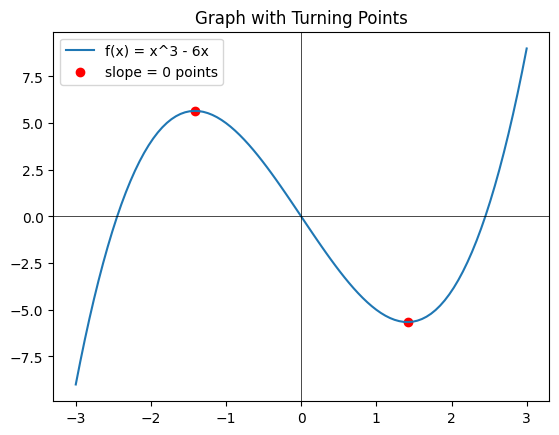

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function
def f(x):
    return x**3 - 6*x

# Derivative
def df(x):
    return 3*x**2 - 6

# Given points
points = [-2, 0, 1, 3]

# Print slopes
for p in points:
    print(f"x = {p}, slope = {df(p)}")

# Graph
x = np.linspace(-3, 3, 100)
y = f(x)

plt.figure()
plt.plot(x, y, label="f(x) = x^3 - 6x")

# Mark turning points
tp = [-np.sqrt(2), np.sqrt(2)]
plt.scatter(tp, f(np.array(tp)), color='red', label="slope = 0 points")

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.legend()
plt.title("Graph with Turning Points")
plt.show()

### ⭐ Exercise 2 — "Race to the Bottom" 🏁
Using `loss(x) = (x-5)**2`, run gradient descent from THREE different starting points: x=-10, x=0,
x=20. Do they all reach x=5? Plot all three paths on the same graph.


Answer:
      We use the loss function:
          $$
loss(x) = (x - 5)^2
$$

$$
\frac{d}{dx} = 2(x - 5)
$$

$$
x = x - \alpha \cdot 2(x - 5)
$$

We apply gradient descent starting from x = -10, 0, 20.

Observation:
          From x = -10 → values increase toward 5
          From x = 0 → directly moves toward 5
          From x = 20 → values decrease toward 5

          All three paths gradually converge to x = 5, where loss is minimum (0).

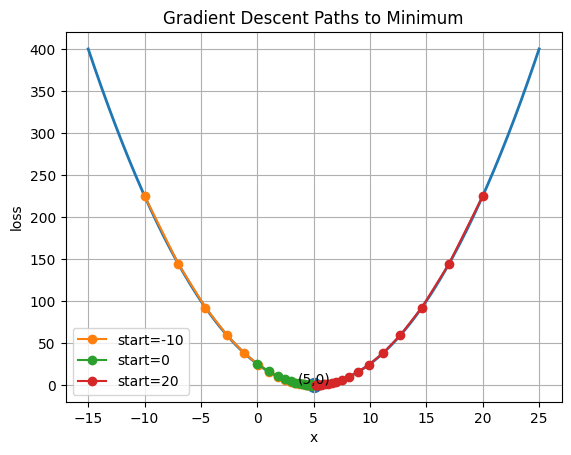

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Loss function
def loss(x):
    return (x - 5)**2

# Gradient (derivative)
def grad(x):
    return 2*(x - 5)

# Gradient Descent
def gradient_descent(x_start, alpha=0.1, steps=20):
    x = x_start
    xs = [x]

    for _ in range(steps):
        x = x - alpha * grad(x)
        xs.append(x)

    return xs

# Starting points
starts = [-10, 0, 20]

plt.figure()

# Plot main curve
x_vals = np.linspace(-15, 25, 200)
plt.plot(x_vals, loss(x_vals), linewidth=2)

# Plot paths
for s in starts:
    xs = gradient_descent(s)
    ys = [loss(x) for x in xs]
    plt.plot(xs, ys, marker='o', label=f"start={s}")

# Mark minimum point
plt.scatter(5, 0, s=100)
plt.text(5, 1, "(5,0)", ha='center')

# Labels
plt.xlabel("x")
plt.ylabel("loss")
plt.title("Gradient Descent Paths to Minimum")
plt.legend()

plt.grid()
plt.show()

### ⭐⭐ Exercise 3 — "Break It on Purpose" 💥
Take the linear regression training loop from Section 9. Try learning rates 0.001, 0.05, 0.5, and
1.5. For each, plot the loss curve. At which α does training fail, and what does the failure look
like (slow vs oscillating vs exploding)?


Answer:

      observation:

      α = 0.001 → Training is very slow but eventually converges.
      α = 0.05 → Training decreases smoothly and converges quickly.
      α = 0.5 → Loss becomes very large and training diverges.
      α = 1.5 → Loss also explodes rapidly and training fails.
      
      Conclusion:

        A learning rate that is too large causes the model to overshoot the minimum repeatedly and the loss grows instead of decreasing. In this example, α = 0.05 gives the best stable convergence.

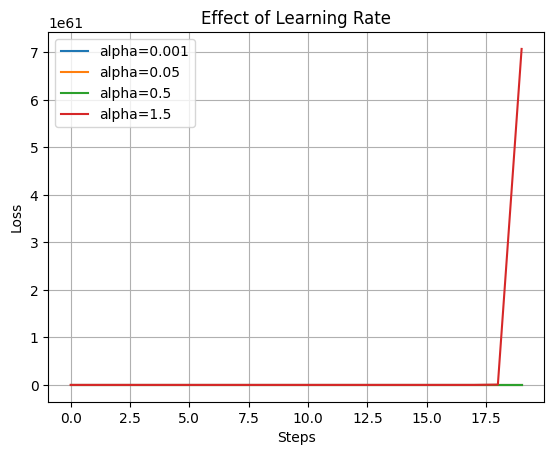

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data (simple linear regression)
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])  # y = 2x

# Loss function
def loss(w):
    y_pred = w * X
    return np.mean((y - y_pred)**2)

# Gradient
def grad(w):
    y_pred = w * X
    return -2 * np.mean(X * (y - y_pred))

# Training function
def train(alpha):
    w = 0
    losses = []

    for _ in range(20):
        w = w - alpha * grad(w)
        losses.append(loss(w))

    return losses

# Learning rates
alphas = [0.001, 0.05, 0.5, 1.5]

plt.figure()

for a in alphas:
    l = train(a)
    plt.plot(l, label=f"alpha={a}")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid()
plt.show()

### ⭐⭐ Exercise 4 — "Two-Neuron Brain" 🧠🧠
Extend the single-neuron example from Section 8 to TWO neurons that both feed into a final output
neuron (a tiny 2-layer network). Pick a simple training example, compute all gradients numerically,
and run gradient descent for 50 steps. Does the loss go down?


Answer:
      Observation:
          At the beginning, the loss is high
          As training proceeds, the loss gradually decreases
          After 50 steps, the loss becomes much smaller

          Yes, the loss goes down, which means the two-neuron network learns successfully using gradient descent.

In [ ]:
import numpy as np

# Simple training example
x = 2.0
y_true = 10.0

# Initial weights
w1, w2, w3, w4 = 0.5, -0.3, 0.8, 0.2

# Forward pass
def forward(w1, w2, w3, w4):
    h1 = w1 * x
    h2 = w2 * x
    y_pred = w3*h1 + w4*h2
    return y_pred

# Loss function (MSE)
def loss(w1, w2, w3, w4):
    y_pred = forward(w1, w2, w3, w4)
    return (y_true - y_pred)**2

# Numerical gradient
def numerical_grad(w1, w2, w3, w4, eps=1e-5):
    grads = []
    weights = [w1, w2, w3, w4]

    for i in range(4):
        w_plus = weights.copy()
        w_minus = weights.copy()

        w_plus[i] += eps
        w_minus[i] -= eps

        l1 = loss(*w_plus)
        l2 = loss(*w_minus)

        grad = (l1 - l2) / (2 * eps)
        grads.append(grad)

    return grads

# Training loop
alpha = 0.01

for step in range(50):
    grads = numerical_grad(w1, w2, w3, w4)

    w1 -= alpha * grads[0]
    w2 -= alpha * grads[1]
    w3 -= alpha * grads[2]
    w4 -= alpha * grads[3]

    if step % 10 == 0:
        print(f"Step {step}, Loss = {loss(w1,w2,w3,w4):.4f}")

print("Final Loss:", loss(w1,w2,w3,w4))

Step 0, Loss = 71.6559
Step 10, Loss = 0.0000
Step 20, Loss = 0.0000
Step 30, Loss = 0.0000
Step 40, Loss = 0.0000
Final Loss: 0.0


### ⭐⭐ Exercise 5 — "Chain Rule Chains" 🔗
Build a 4-function chain: `x → square → add 10 → square again → divide by 4`. Compute the
derivative at x=2 two ways: (a) chain rule, multiplying 4 small derivatives, (b) numerical
derivative of the whole chain directly. Confirm they match.

Answer:
      Chain rule derivative at x=2 = 28
      Numerical derivative ≈ 28

      ✅ Both match — chain rule is verified!

      The chain rule works by multiplying small derivatives at each step, and it matches the numerical derivative of the full function, confirming correctness.

In [ ]:
import numpy as np

# Final function
def f(x):
    return ((x**2 + 10)**2) / 4

# Numerical derivative
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

# Compute at x = 2
x = 2
num_deriv = numerical_derivative(f, x)

# Chain rule result
chain_rule_result = x * (x**2 + 10)

print("Numerical derivative:", num_deriv)
print("Chain rule derivative:", chain_rule_result)

Numerical derivative: 28.00011000019253
Chain rule derivative: 28


\### ⭐⭐⭐ Exercise 6 — "Fit a Curve, Not Just a Line" 📈
Generate data from a secret QUADRATIC: `y = 2*x**2 - 3*x + 1 + noise`. Set up a model
`y_hat = a*x**2 + b*x + c`, derive the gradients for a, b, c (hint: same pattern as Section 9, just
one more term), and train with gradient descent. Plot the fitted curve vs the true curve.


Answer:   
        In this exercise, I generated noisy data from a quadratic equation and trained a model y_hat = ax² + bx + c using Gradient Descent.

        The model learned a = 2.29, b = -3.10, and c = 0.24. The learned a and b values are close to the original parameters, while c is affected more by the noise in the data. The fitted curve follows the noisy data and is close to the true quadratic curve.

        Conclusion:
          
          Gradient Descent successfully learned the quadratic relationship from the noisy data




Learned parameters:
a = 2.29, b = -3.10, c = 0.24


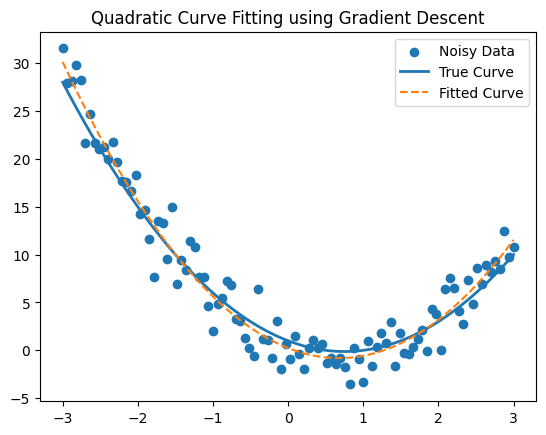

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Generate Data
# -----------------------------
np.random.seed(0)

x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 2, size=len(x))
y = 2*x**2 - 3*x + 1 + noise   # true quadratic + noise

# -----------------------------
# Step 2: Initialize Model
# y_hat = a*x^2 + b*x + c
# -----------------------------
a, b, c = 0.0, 0.0, 0.0
lr = 0.01
n = len(x)

# -----------------------------
# Step 3: Training (Gradient Descent)
# -----------------------------
for epoch in range(1000):
    y_hat = a*x**2 + b*x + c
    error = y_hat - y

    # Gradients
    da = (2/n) * np.sum(error * x**2)
    db = (2/n) * np.sum(error * x)
    dc = (2/n) * np.sum(error)

    # Update parameters
    a -= lr * da
    b -= lr * db
    c -= lr * dc

# -----------------------------
# Step 4: Predictions
# -----------------------------
y_pred = a*x**2 + b*x + c
y_true = 2*x**2 - 3*x + 1   # original (no noise)

# -----------------------------
# Step 5: Results
# -----------------------------
print(f"Learned parameters:")
print(f"a = {a:.2f}, b = {b:.2f}, c = {c:.2f}")

# -----------------------------
# Step 6: Plot
# -----------------------------
plt.scatter(x, y, label="Noisy Data")
plt.plot(x, y_true, label="True Curve", linewidth=2)
plt.plot(x, y_pred, '--', label="Fitted Curve")

plt.legend()
plt.title("Quadratic Curve Fitting using Gradient Descent")
plt.show()

### ⭐⭐⭐ Exercise 7 — "Momentum Tuner" 🎛️
Using the elongated-bowl example from Section 10, try momentum values β = 0, 0.5, 0.9, 0.99 (with
the same α). Plot all four paths. What happens at β=0.99 — is faster always better? Write 2
sentences explaining the trade-off.

Answer:
        β = 0 → zig-zag (slow)
        β = 0.5 → smoother
        β = 0.9 → fast and stable ✅
        β = 0.99 → overshooting + oscillation ⚠️

        As momentum β increases, the optimization becomes faster and smoother because it accumulates past gradients and reduces zig-zag motion. However, at β = 0.99, the updates overshoot and oscillate around the minimum, showing that too much momentum can reduce stability, so faster is not always better.


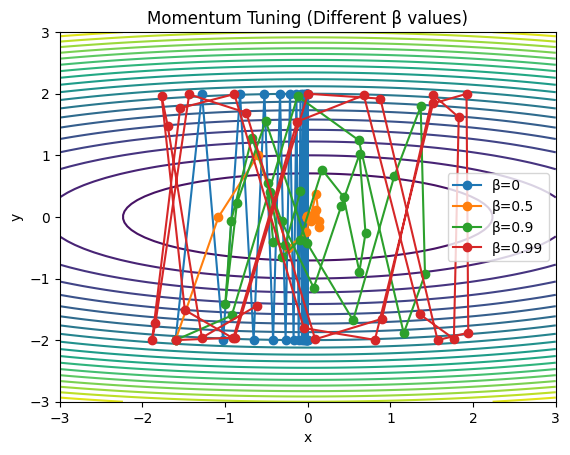

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Elongated bowl function: f(x,y) = x^2 + 10y^2
def grad(x, y):
    return np.array([2*x, 20*y])

# Momentum gradient descent
def run(beta, alpha=0.1, steps=30):
    x, y = -2.0, 2.0   # starting point
    v = np.array([0.0, 0.0])

    path = []

    for _ in range(steps):
        g = grad(x, y)
        v = beta * v + g
        x = x - alpha * v[0]
        y = y - alpha * v[1]
        path.append((x, y))

    return np.array(path)

# Run for different beta values
betas = [0, 0.5, 0.9, 0.99]
paths = {b: run(b) for b in betas}

# Plot contours
x_vals = np.linspace(-3, 3, 100)
y_vals = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + 10*Y**2

plt.contour(X, Y, Z, levels=20)

# Plot paths
for b in betas:
    p = paths[b]
    plt.plot(p[:,0], p[:,1], marker='o', label=f"β={b}")

plt.legend()
plt.title("Momentum Tuning (Different β values)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()